
Con  riferimento  al  data  set  dell’esercitazione  su  clustering,  eseguire  una  classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 

Procedere  allo  split  train-test  secondo  il  rapporto  95%-15%  in  forma  stratificata 
secondo i valori della variabile target. 

2.Eseguire  l’imputazione  dei  dati  mancanti  con  le  stesse  strategie  dell’esercitazione 
precedente. 

3.Rimuovere  le  feature  che  presentano  elevata  correlazione  con  la  variabile  target  e 
successivamente analizzare le possibili feature multicollineari rimanenti. 

4.Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

5.Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

#split dataset

df = pd.read_csv('dataset_esercitazione.csv')

df = df.drop(columns=['dzgroup','aps'])


X = df.drop(columns=['death'])
y = df.death

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size=0.15, random_state=42, stratify=df['death']) 



Gestire i dati mancanti applicando imputazione con mediana per le variabili numeriche e con un valore 
costante (ad esempio "Unknown") per quelle categoriche; successivamente codificare le variabili categoriche 
tramite Ordinal Encoding.

In [2]:
from sklearn.impute import SimpleImputer
#imputazione dei dati mancanti

imputer1 = SimpleImputer(strategy='median').set_output(transform="pandas")
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform="pandas")

num_feature = X_train.select_dtypes(include=['number']).columns.tolist()
cat_feature = [ column  for column in X_train.columns if column not in num_feature]

print(num_feature)
print(cat_feature)

X_tr_num = imputer1.fit_transform( X_train[num_feature])
X_tr_cat = imputer2.fit_transform( X_train[cat_feature])

X_te_num = imputer1.transform( X_test[num_feature] )
X_te_cat = imputer2.transform( X_test[cat_feature] )



['age', 'num.co', 'edu', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'sps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'prg2m', 'prg6m', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'adlsc']
['sex', 'dzclass', 'income', 'race', 'ca', 'dnr']


In [3]:
from sklearn.preprocessing import OrdinalEncoder
#encoder delle feature categoriche


encoder = OrdinalEncoder().set_output(transform='pandas')

X_tr_encode = encoder.fit_transform( X_tr_cat )

X_te_encode = encoder.transform( X_te_cat )

X_train = pd.concat( [X_tr_num, X_tr_encode], axis=1 )

X_test = pd.concat( [X_te_num, X_te_encode], axis=1 )



3.Rimuovere  le  feature  che  presentano  elevata  correlazione  con  la  variabile  target  e 
successivamente analizzare le possibili feature multicollineari rimanenti. 

In [4]:
#scaling delle feature
#per effettuare l'analisi delle correlazione è meglio prima fare lo scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_feature] = scaler.fit_transform( X_train[num_feature] )
X_test[num_feature] = scaler.transform( X_test[num_feature] )

print(X_train.shape)

(7739, 40)


In [5]:
import numpy as np
#analisi della matrice di correlazione
corr_matrix = X_train.corr().abs() #la calcolo in valore assoluto cosi non mi devo preoccupare dei valori negativi

threshold = 0.7

num_column = len(corr_matrix.columns)
for i in range(num_column):
    for j in range(i+1, num_column):
        
        
        valore_corr = corr_matrix.iloc[i,j]
        
        if valore_corr > threshold:
            
            colonna_da_eliminare = corr_matrix.columns[j]
            X_train = X_train.drop( columns=[colonna_da_eliminare] )
            X_test = X_test.drop( columns=[colonna_da_eliminare] )
            
            print('elimino colonna: ', colonna_da_eliminare)





elimino colonna:  totcst
elimino colonna:  surv2m
elimino colonna:  surv6m
elimino colonna:  prg6m
elimino colonna:  adlsc


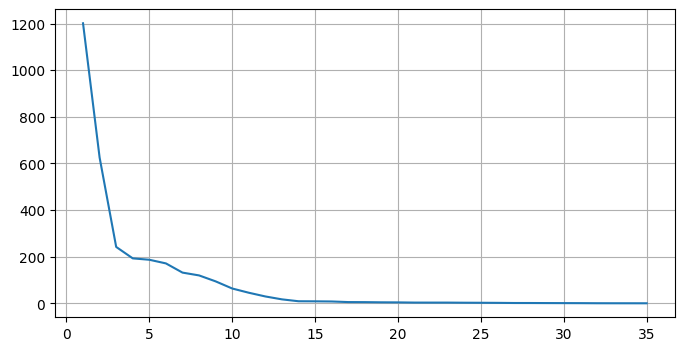

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

selector = SelectKBest(f_classif, k='all').fit(X_train, y_train)

scores = sorted(selector.scores_, reverse=True)

plt.figure(figsize=(8,4))
plt.plot(range(1,len(scores)+1), scores)
plt.grid(True)
plt.show()

Vedere quali feature a livello statistico mi aiutano di piu nella predizione

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif,k=18)
x_train_selected = selector.fit_transform(X_train, y_train)
x_test_selected = selector.transform(X_test)

print(x_train_selected.shape)

(7739, 15)


4.Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a.Classificatore 
i.criterion: “gini”, “log_loss” 
ii.min_samples_split: 2, 5, 10 
iii.max_features: “sqrt”, 5 
b.Regressore 
i.criterion: “squared_error”, “absolute_error” 
ii.min_samples_split: 2, 5, 10 
iii.max_features: “sqrt”, 5 


5.Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest

In [8]:

'''
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
param_grid{
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}


models = []

for criterion in criterions:
    for min_samples_split in min_samples_splits:
        for max_features in max_features_list:
            
            classifier = RandomForestClassifier(
                criterion=criterion, 
                min_samples_split=min_samples_split, 
                max_features=max_features,
            )
            
            classifier.fit(X_train, y_train)
            
            # 2. Estrai le probabilità per la classe positiva sul TEST SET
            y_score = classifier.predict_proba(X_test)[:, 1]
            
            # 3. CORRETTO: Calcola l'AUC usando y_test coerentemente con y_score
            auc_score = roc_auc_score(y_test, y_score)
            
            # 4. Calcola i punti geometrici per la curva ROC
            fpr, tpr, thresholds = roc_curve(y_test, y_score)
            
            model = {
                'params': {'criterion': criterion, 'min_samples_split': min_samples_split, 'max_features': max_features},
                'y_score': y_score,
                'auc_score': auc_score,
                'roc_curve': [fpr, tpr, thresholds]
            }
            
            models.append(model)
            
'''

"\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import roc_curve, roc_auc_score\nfrom sklearn.model_selection import GridSearchCV\nparam_grid{\n    'criterion': ['gini', 'log_loss'],\n    'min_samples_split': [2, 5, 10],\n    'max_features': ['sqrt', 5]\n}\n\n\nmodels = []\n\nfor criterion in criterions:\n    for min_samples_split in min_samples_splits:\n        for max_features in max_features_list:\n\n            classifier = RandomForestClassifier(\n                criterion=criterion, \n                min_samples_split=min_samples_split, \n                max_features=max_features,\n            )\n\n            classifier.fit(X_train, y_train)\n\n            # 2. Estrai le probabilità per la classe positiva sul TEST SET\n            y_score = classifier.predict_proba(X_test)[:, 1]\n\n            # 3. CORRETTO: Calcola l'AUC usando y_test coerentemente con y_score\n            auc_score = roc_auc_score(y_test, y_score)\n\n            # 4. Calcola i punt

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}


grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc', 

)

grid_search.fit(x_train_selected, y_train)

best_classifier = grid_search.best_estimator_
best_params = grid_search.best_params_
best_params_name = f"RF(criterion={best_params['criterion']}, split={best_params['min_samples_split']}, feat={best_params['max_features']})"

y_score =  best_classifier.predict_proba(x_test_selected)[:,1]
auc_score = roc_auc_score(y_test, y_score)
fpr, tpr, thresholds = roc_curve(y_test, y_score)

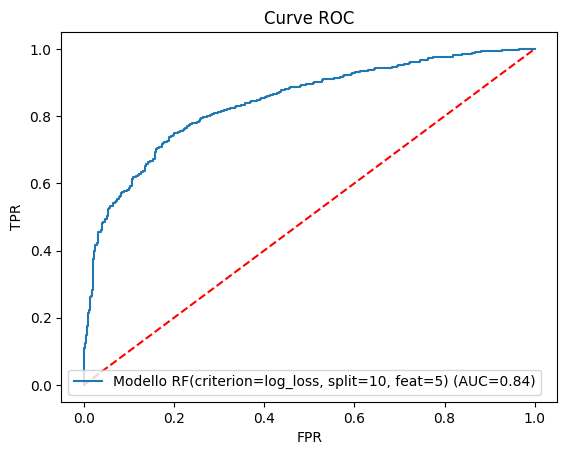

In [10]:
import matplotlib.pyplot as plt 


plt.figure()


plt.plot(fpr,tpr, label=f"Modello {best_params_name} (AUC={auc_score:.2f})")
    
# 3. Linea casuale di riferimento (obbligatoria all'esame)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


# 4. Etichette degli assi e titolo
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curve ROC')
plt.legend() # Mostra la legenda

# 5. Mostra il grafico
plt.show()